In [51]:
# Einfluss von Wetterbedingungen auf Flugverspätungen
## Flughafen Wien (Vienna International Airport) Gruppe 9

In [52]:
# 1. Imports & Setup

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient

# Für konsistente und gut lesbare Visualisierungen
sns.set(style="whitegrid")

In [53]:
# 2. MongoDB-Verbindung herstellen

# Verbindung zu lokalem MongoDB-Server
client = MongoClient('mongodb://localhost:27017/')

# Datenbank auswählen
db = client['fluege_wetter']

# Collections definieren
flights_collection = db['flights']
weather_collection = db['weather']

# Vorhandene Collections anzeigen (Kontrolle)
print("Collections in der Datenbank:", db.list_collection_names())

Collections in der Datenbank: ['weather', 'flights']


In [54]:
# 3. Daten laden & mergen

# Flugdaten und Wetterdaten laden
flights = pd.read_csv('all_pre_departure_delays_2025.csv')
weather = pd.read_csv('weather.csv', decimal=',')

# Zeitspalten in echtes Datumsformat umwandeln
flights['scheduled_departure'] = pd.to_datetime(flights['FLT_DATE'])
weather['datetime'] = pd.to_datetime(weather['date'])

# NUR WIEN (LOWW) direkt nach dem Laden
flights = flights[flights['APT_ICAO'] == 'LOWW']

# Merge der Flugdaten mit den Wetterdaten anhand des Abflugdatums
df_merged = pd.merge(
    flights,
    weather,
    left_on='scheduled_departure',
    right_on='datetime',
    how='left'
)

In [55]:
# 4. Daten in MongoDB importieren

# Alte Daten löschen (damit keine Duplikate entstehen)
flights_collection.delete_many({})
weather_collection.delete_many({})

# Flugdaten (nur Wien) speichern
flights_collection.insert_many(flights.to_dict('records'))

# Wetterdaten vollständig speichern (werden später über Datum verknüpft)
weather_collection.insert_many(weather.to_dict('records'))

# Bestätigung
print("Daten erfolgreich in MongoDB importiert!")

Daten erfolgreich in MongoDB importiert!


In [56]:
# 5. Daten aus MongoDB abrufen

# Flugdaten aus MongoDB laden und in DataFrame umwandeln
df_flights = pd.DataFrame(list(flights_collection.find()))

# Wetterdaten aus MongoDB laden
df_weather = pd.DataFrame(list(weather_collection.find()))

# MongoDB erzeugt automatisch eine _id-Spalte → für Analyse meist nicht notwendig
df_flights.drop(columns=['_id'], errors='ignore', inplace=True)
df_weather.drop(columns=['_id'], errors='ignore', inplace=True)

# Erste Zeilen prüfen (Kontrolle, ob Import funktioniert hat)
print("Flugdaten:")
print(df_flights.head())

print("\nWetterdaten:")
print(df_weather.head())

Flugdaten:
   YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO APT_NAME STATE_NAME  \
0  2025          1       JAN  2025-01-01     LOWW   Vienna    Austria   
1  2025          1       JAN  2025-01-02     LOWW   Vienna    Austria   
2  2025          1       JAN  2025-01-03     LOWW   Vienna    Austria   
3  2025          1       JAN  2025-01-04     LOWW   Vienna    Austria   
4  2025          1       JAN  2025-01-05     LOWW   Vienna    Austria   

   FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2 scheduled_departure  
0        253          253.0         3015.0          2025-01-01  
1        310          310.0         5975.0          2025-01-02  
2        335          335.0         5809.0          2025-01-03  
3        267          267.0         5214.0          2025-01-04  
4        302          302.0         8692.0          2025-01-05  

Wetterdaten:
                  date  tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt  \
0  2025-01-01 00:00:00  -3.4  -4.0  -2.8   0.0   NaN   NaN  14.7  27.8  

In [57]:
# 6. Flugdaten & Wetterdaten zusammenführen

# Datum vereinheitlichen (nur Datum, kein Uhrzeitanteil)
df_flights['scheduled_departure'] = pd.to_datetime(df_flights['scheduled_departure']).dt.date
df_weather['datetime'] = pd.to_datetime(df_weather['datetime']).dt.date

# Merge über Datum
df_merged = pd.merge(
    df_flights,
    df_weather,
    left_on='scheduled_departure',
    right_on='datetime',
    how='left'
)

# unnötige Spalten entfernen
df_merged.drop(columns=['key_0'], errors='ignore', inplace=True)

# Verspätung pro Flug berechnen (vektorisiert, deutlich schneller als apply)
df_merged['delay_per_flight'] = df_merged['DLY_ALL_PRE_2'] / df_merged['FLT_DEP_1']

# Ergebnis prüfen
print("Zusammengeführte Daten:")
print(df_merged.round(2).head())

Zusammengeführte Daten:
   YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO APT_NAME STATE_NAME  \
0  2025          1       JAN  2025-01-01     LOWW   Vienna    Austria   
1  2025          1       JAN  2025-01-02     LOWW   Vienna    Austria   
2  2025          1       JAN  2025-01-03     LOWW   Vienna    Austria   
3  2025          1       JAN  2025-01-04     LOWW   Vienna    Austria   
4  2025          1       JAN  2025-01-05     LOWW   Vienna    Austria   

   FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2  ... tmax prcp  snow  wdir  wspd  \
0        253          253.0         3015.0  ... -2.8  0.0   NaN   NaN  14.7   
1        310          310.0         5975.0  ... -0.4  NaN   NaN   NaN  17.4   
2        335          335.0         5809.0  ...  4.4  NaN   NaN   NaN  23.4   
3        267          267.0         5214.0  ...  3.1  0.0   NaN   NaN  18.0   
4        302          302.0         8692.0  ...  0.3  NaN   NaN   NaN  18.0   

   wpgt    pres   tsun    datetime  delay_per_flight  
0  27.8

Durchschnittliche Verspätung nach Temperaturbereich:
temp_range
(-10, 0]    11.34
(0, 10]     10.21
(10, 20]    12.29
(20, 30]    18.49
Name: delay_per_flight, dtype: float64


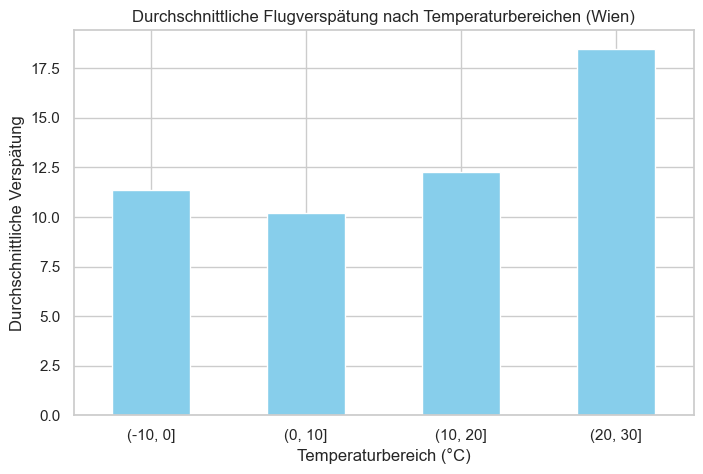

In [58]:
# 7. Analyse: Durchschnittliche Verspätung nach Temperaturbereichen

# Temperaturbereiche definieren (°C)
temp_bins = [-10, 0, 10, 20, 30]
df_merged['temp_range'] = pd.cut(df_merged['tavg'], bins=temp_bins)

# Durchschnittliche Verspätung pro Temperaturbereich berechnen
avg_delay = df_merged.groupby('temp_range', observed=True)['delay_per_flight'].mean()

# Ausgabe
print("Durchschnittliche Verspätung nach Temperaturbereich:")
print(avg_delay.round(2))

# Visualisierung
avg_delay.plot(kind='bar', figsize=(8,5), color='skyblue')

plt.xlabel("Temperaturbereich (°C)")
plt.ylabel("Durchschnittliche Verspätung")
plt.title("Durchschnittliche Flugverspätung nach Temperaturbereichen (Wien)")
plt.xticks(rotation=0)
plt.show()

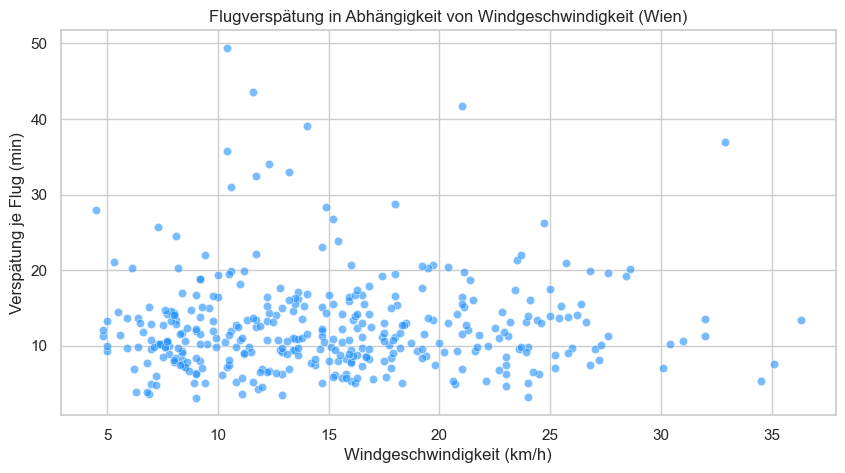

In [59]:
# 8. Analyse: Flugverspätung in Abhängigkeit von Windgeschwindigkeit

# Sicherstellen, dass Flugdaten und Wetterdaten zusammengeführt sind
df_merged_wind = pd.merge(
    df_flights,
    df_weather,
    left_on='scheduled_departure',
    right_on='datetime',
    how='left'
)

# Verspätung pro Flug berechnen
# (Vermeidung von Division durch 0)
df_merged_wind['delay_per_flight'] = (
    df_merged_wind['DLY_ALL_PRE_2'] / df_merged_wind['FLT_DEP_1'].replace(0, pd.NA)
)

# Fehlende Windwerte behandeln (optional, aber stabiler für Plot)
df_merged_wind['wspd'] = df_merged_wind['wspd'].fillna(0)

# Scatterplot: Zusammenhang zwischen Wind und Verspätung
plt.figure(figsize=(10, 5))

sns.scatterplot(
    x='wspd',
    y='delay_per_flight',
    data=df_merged_wind,
    color='dodgerblue',
    alpha=0.6
)

# Achsenbeschriftungen und Titel
plt.xlabel("Windgeschwindigkeit (km/h)")
plt.ylabel("Verspätung je Flug (min)")
plt.title("Flugverspätung in Abhängigkeit von Windgeschwindigkeit (Wien)")

plt.show()

Aggregierte Daten nach Temperatur:
    tavg  avg_delay
0     -4       9.26
1     -3      11.71
2     -2      12.20
3     -1      12.10
4      0      11.20
5      1      11.82
6      2      10.97
7      3      10.32
8      4       9.19
9      5      10.84
10     6       7.15
11     7       9.55
12     8       7.99
13     9      10.98
14    10      10.32
15    11      10.24
16    12      11.98
17    13      11.12
18    14       9.94
19    15      11.29
20    16      10.29
21    17      12.90
22    18      15.77
23    19      15.09
24    20      21.23
25    21      15.95
26    22      19.66
27    23      15.73
28    24      18.06
29    25      14.19
30    26      21.39
31    27      20.87


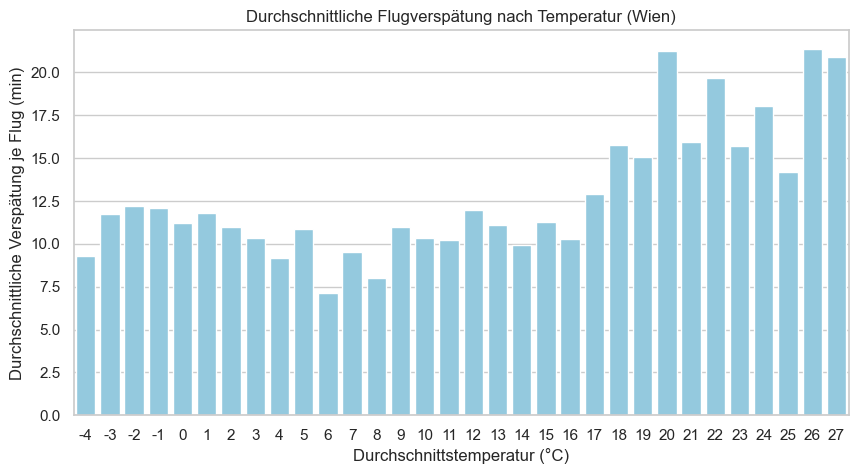

In [60]:
# 9. Analyse: Durchschnittliche Verspätung nach Temperatur

# Pipeline definieren für Aggregation in MongoDB
pipeline_temp = [
    {
        "$lookup": {
            "from": "weather",
            "localField": "scheduled_departure",
            "foreignField": "datetime",
            "as": "weather_info"
        }
    },
    {
        "$unwind": "$weather_info"
    },

    # Gruppieren nach Temperatur (abgerundet)
    {
        "$group": {
            "_id": { "$floor": "$weather_info.tavg" },
            "avg_delay": {
                "$avg": {
                    "$divide": ["$DLY_ALL_PRE_2", "$FLT_DEP_1"]
                }
            }
        }
    },

    {
        "$sort": { "_id": 1 }
    }
]

# Aggregation ausführen
result = list(flights_collection.aggregate(pipeline_temp))

# In DataFrame umwandeln
df_agg_temp = pd.DataFrame(result)
df_agg_temp.rename(columns={"_id": "tavg"}, inplace=True)

# X-Achse sauber machen (keine Nachkommastellen)
df_agg_temp["tavg"] = df_agg_temp["tavg"].astype(int)

# Ergebnis prüfen
print("Aggregierte Daten nach Temperatur:")
print(df_agg_temp.round(2))

# Visualisierung
plt.figure(figsize=(10,5))
sns.barplot(x="tavg", y="avg_delay", data=df_agg_temp, color='skyblue')

# Achsenbeschriftungen und Titel
plt.xlabel("Durchschnittstemperatur (°C)")
plt.ylabel("Durchschnittliche Verspätung je Flug (min)")
plt.title("Durchschnittliche Flugverspätung nach Temperatur (Wien)")
plt.show()

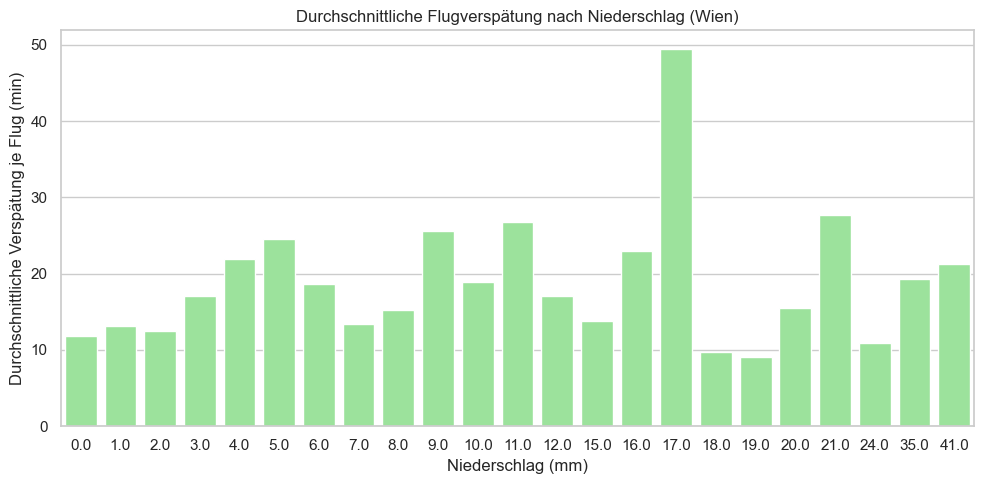

In [61]:
# 10. Analyse: Durchschnittliche Flugverspätung nach Niederschlag

# Pipeline definieren für Aggregation in MongoDB
pipeline_prcp = [
    {
        "$lookup": {
            "from": "weather",
            "localField": "scheduled_departure",
            "foreignField": "datetime",
            "as": "weather_info"
        }
    },

    # Weather-Array auflösen
    { "$unwind": "$weather_info" },

    # Gruppieren nach Niederschlag (abgerundet)
    {
        "$group": {
            "_id": { "$floor": "$weather_info.prcp" },
            "avg_delay": {
                "$avg": {
                    "$divide": ["$DLY_ALL_PRE_2", "$FLT_DEP_1"]
                }
            }
        }
    },

    # Sortieren nach Niederschlag
    {
        "$sort": { "_id": 1 }
    }
]

# Aggregation ausführen
result_prcp = list(flights_collection.aggregate(pipeline_prcp))

# In DataFrame umwandeln
df_prcp = pd.DataFrame(result_prcp)
df_prcp.rename(columns={"_id": "prcp"}, inplace=True)

# Visualisierung
plt.figure(figsize=(10,5))
sns.barplot(
    x="prcp",
    y="avg_delay",
    data=df_prcp,
    color='lightgreen'
)

# Achsenbeschriftungen und Titel
plt.xlabel("Niederschlag (mm)")
plt.ylabel("Durchschnittliche Verspätung je Flug (min)")
plt.title("Durchschnittliche Flugverspätung nach Niederschlag (Wien)")
plt.tight_layout()
plt.show()

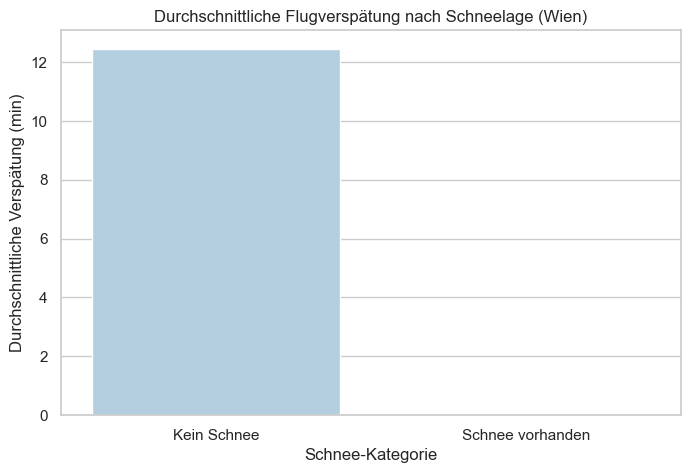

In [62]:
# 11. Analyse: Durchschnittliche Flugverspätung nach Schneelage

# Schnee NaN -> 0 setzen
df_merged['snow'] = df_merged['snow'].fillna(0)

# Schnee-Kategorisierung
df_merged['snow_category'] = df_merged['snow'].apply(
    lambda x: 'Kein Schnee' if x == 0 else 'Schnee vorhanden'
)

# Durchschnittliche Verspätung berechnen
avg_delay_snow = (
    df_merged
    .groupby('snow_category')['delay_per_flight']
    .mean()
    .reset_index()
)

# Sicherstellen, dass beide Kategorien existieren
all_categories = ['Kein Schnee', 'Schnee vorhanden']
avg_delay_snow = (
    avg_delay_snow
    .set_index('snow_category')
    .reindex(all_categories)
    .reset_index()
)

# Visualisierung
plt.figure(figsize=(8, 5))

sns.barplot(
    x='snow_category',
    y='delay_per_flight',
    data=avg_delay_snow,
    hue='snow_category',   # wichtig wegen FutureWarning
    palette='Blues',
    legend=False
)

# Achsenbeschriftungen und Titel
plt.xlabel("Schnee-Kategorie")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Flugverspätung nach Schneelage (Wien)")
plt.show()

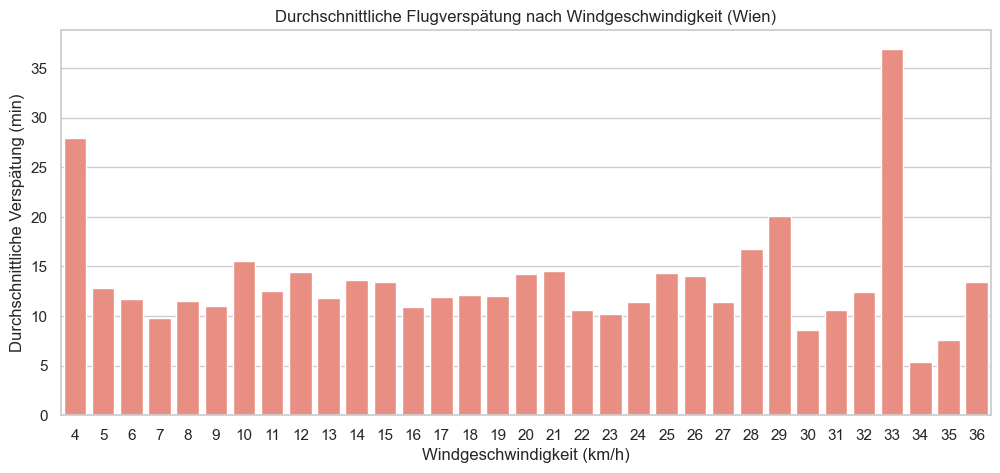

In [63]:
# 12. Analyse: Durchschnittliche Flugverspätung nach Windgeschwindigkeit

# Merge direkt durchführen
df_merged_copy = pd.merge(
    df_flights,
    df_weather.assign(wspd=df_weather['wspd'].fillna(0)),
    left_on='scheduled_departure',
    right_on='datetime',
    how='left'
)

# Verspätung berechnen
df_merged_copy['delay_per_flight'] = (
    df_merged_copy['DLY_ALL_PRE_2'] / df_merged_copy['FLT_DEP_1']
)

# Windgeschwindigkeit runden
df_merged_copy['wspd_floor'] = df_merged_copy['wspd'].round(0).astype(int)

# Gruppieren
df_wind_plot = (
    df_merged_copy
    .groupby('wspd_floor')['delay_per_flight']
    .mean()
    .reset_index()
)

# Visualisierung
plt.figure(figsize=(12, 5))

sns.barplot(
    x='wspd_floor',
    y='delay_per_flight',
    data=df_wind_plot,
    color='salmon'
)

# Achsenbeschriftungen und Titel
plt.xlabel("Windgeschwindigkeit (km/h)")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Flugverspätung nach Windgeschwindigkeit (Wien)")
plt.show()

Ergebnis:
    month  delay_per_flight
0       1              9.75
1       2              7.56
2       3              6.82
3       4             10.17
4       5             10.16
5       6             15.59
6       7             20.26
7       8             15.46
8       9             14.58
9      10             14.12
10     11              9.79
11     12             14.71


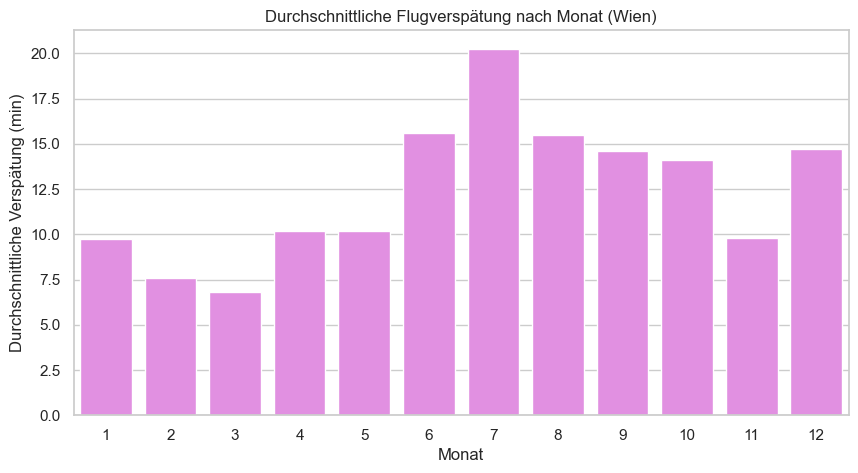

In [64]:
# 13. Analyse: Durchschnittliche Flugverspätung pro Flug nach Monat

# Basisdaten (Flüge)
df_merged_monat = df_flights.copy()

# Datum in datetime umwandeln
df_merged_monat['scheduled_departure'] = pd.to_datetime(df_merged_monat['scheduled_departure'])

# Monat extrahieren
df_merged_monat['month'] = df_merged_monat['scheduled_departure'].dt.month

# Verspätung pro Flug berechnen (Division durch 0 vermeiden)
df_merged_monat['delay_per_flight'] = (
    df_merged_monat['DLY_ALL_PRE_2'] / df_merged_monat['FLT_DEP_1'].replace(0, pd.NA)
)

# monatlicher Durchschnitt
df_month_plot = (
    df_merged_monat
    .groupby('month')['delay_per_flight']
    .mean()
    .reset_index()
)

# Ergebnis ausgeben
df_month_plot = df_month_plot.round(2)
print("Ergebnis:")
print(df_month_plot)

# Visualisierung
plt.figure(figsize=(10, 5))

sns.barplot(
    x='month',
    y='delay_per_flight',
    data=df_month_plot,
    color='violet'
)

# Achsenbeschriftungen und Titel
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Flugverspätung nach Monat (Wien)")

plt.show()

Ergebnis:
    month  avg_delay
0       1       9.75
1       2       7.56
2       3       6.82
3       4      10.17
4       5      10.16
5       6      15.59
6       7      20.26
7       8      15.46
8       9      14.58
9      10      14.12
10     11       9.79
11     12      14.71


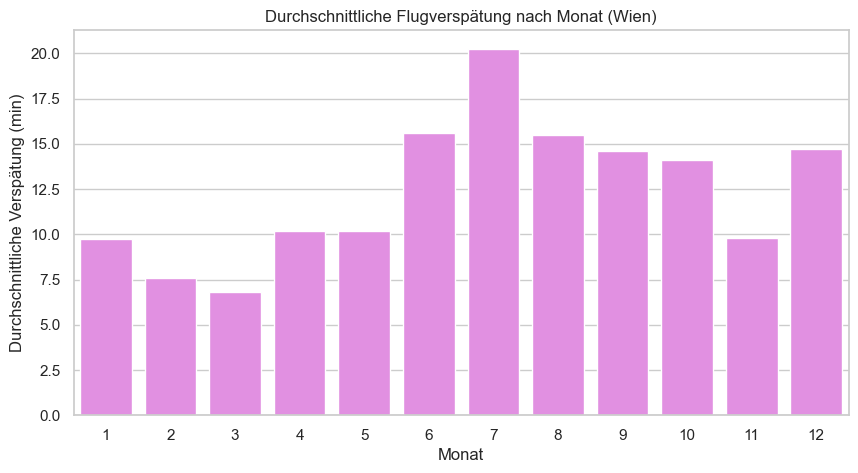

In [65]:
# 14. Analyse: Durchschnittliche Verspätung nach Monat (Aggregation)

pipeline_month = [
    {
        "$project": {
            # Monat aus Datum extrahieren
            "month": { "$month": "$scheduled_departure" },

            # Verspätung pro Flug (normiert wie in allen anderen Analysen)
            "delay_per_flight": {
                "$cond": [
                    {
                        "$and": [
                            { "$gt": ["$FLT_DEP_1", 0] },
                            { "$ne": ["$DLY_ALL_PRE_2", None] }
                        ]
                    },
                    { "$divide": ["$DLY_ALL_PRE_2", "$FLT_DEP_1"] },
                    None
                ]
            }
        }
    },

    # Durchschnitt pro Monat
    {
        "$group": {
            "_id": "$month",
            "avg_delay": { "$avg": "$delay_per_flight" }
        }
    },

    # Sortierung
    {
        "$sort": { "_id": 1 }
    }
]

result = list(flights_collection.aggregate(pipeline_month))

# monatlicher Durchschnitt
df_month = pd.DataFrame(result).rename(columns={"_id": "month"})

# Ergebnis ausgeben
df_month = df_month.round(2)
print("Ergebnis:")
print(df_month)

# Visualisierung
plt.figure(figsize=(10,5))

sns.barplot(
    x="month",
    y="avg_delay",
    data=df_month,
    color="violet"
)

# Achsenbeschriftungen und Titel
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Flugverspätung nach Monat (Wien)")
plt.show()

## Vergleich der Methoden

**Pandas**: einfache, schnelle Analyse für kleinere Datenmengen  

**MongoDB Aggregation (MapReduce)**: skalierbar für große Datenmengen  

**Fazit:** Die Ergebnisse sind ähnlich, jedoch ist die MongoDB-Lösung besser für Big Data geeignet.

## Big Data Kriterien (5Vs)

**Volume:**
- Aktuell kleine bis mittlere Datenmengen (CSV-Dateien, Wetterdaten).  
- Infrastruktur erlaubt aber skalierbare Verarbeitung in MongoDB → geeignet für größere Datenmengen.

**2. Velocity:**  
- Daten stammen aus historischen Flugdaten → statisch.  
- Pipeline könnte aber für Echtzeit-Daten aus API erweitert werden (z.B. Live-Wetter oder Flüge).

**3. Variety:**  
- Zwei verschiedene Datenquellen: Flugdaten (CSV), Wetterdaten (CSV/API).  
- Daten enthalten unterschiedliche Formate: Datum, Temperatur, Niederschlag, Verspätung.

**4. Veracity:**  
- Flugdaten aus offizieller Quelle, Wetterdaten aus verlässlichem Open Data API.  
- Fehlende Werte wurden bereinigt (NaN → 0 oder kategorisiert).

**5. Value:**  
- Erkenntnisse über Einfluss von Wetter auf Flugverspätungen.  
- Möglichkeit, Vorhersagen oder Optimierungen für Flughafen Wien zu entwickeln.


## 4 Levels der Datenverarbeitung

**1. Data Source**  
- Flugdaten (CSV)  
- Wetterdaten (CSV)

**2. Data Storage**  
- MongoDB als NoSQL-Datenbank  
- Vorteil: einfache Aggregation, skalierbar für große Datenmengen, Multiuser-Zugriff

**3. Data Analysis**  
- Pandas: schnelle Analyse für kleine Datenmengen  
- MongoDB Aggregation (MapReduce): skalierbare Berechnung

**4. Data Output / Visualization**  
- Balkendiagramme für Durchschnittsverspätungen nach Temperatur, Wind, Niederschlag, Monat  
- Vergleich Pandas vs. MongoDB Aggregation zeigt Funktionsweise und Skalierbarkeit

## Infrastruktur & Architektur

**Architekturübersicht:**


In [66]:
# Python Version:
import sys
print(f"Python Version: {sys.version}")

# Pandas Version:
import pandas as pd
print(f"Pandas Version: {pd.__version__}")

# Matplotlib Version:
import matplotlib
print(f"Matplotlib Version: {matplotlib.__version__}")

# Seaborn Version:
import seaborn as sns
print(f"Seaborn Version: {sns.__version__}")

# MongoDB-Version:
print(f"Matplotlib Version:") 
!mongod --version | head -n 1

Python Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:16:10) [GCC 11.2.0]
Pandas Version: 2.3.3
Matplotlib Version: 3.10.6
Seaborn Version: 0.13.2
Matplotlib Version:
db version v7.0.31



**Details (23.04.2026):**
- **Python 3.13.9**
- **Pandas 2.3.3**
- **Matplotlib 3.10.6**
- **Seaborn 0.13.2**  
- **MongoDB 7.0.31** als NoSQL-Datenbank für skalierbare Speicherung  
- **Multiuser Setup:** GitHub Repository, Zugriff auf Notebook & Daten für das Team 